

```
SVM an Naive Baye's Assignment
```



1: What is a Support Vector Machine (SVM)?

Ans : A Support Vector Machine (SVM) is a supervised machine learning algorithm used primarily for classification and regression tasks.
Its core objective is to find the optimal decision boundary—called a hyperplane—that separates different classes of data points with the maximum possible distance.

1. Hyperplane: The decision boundary that divides the data space into distinct classes.
    * In 2D, it is a line.
    * In 3D, it is a plane.
    * In N-dimensional space, it is an $(N-1)$-dimensional hyperplane.
2. Support Vectors: The specific data points located closest to the hyperplane. These points anchor and define the position and orientation of the decision boundary.
3. Margin: The distance between the hyperplane and the closest data points (support vectors) from any class. SVM aims to maximize this margin to improve generalization on unseen data.

2: What is the difference between Hard Margin and Soft Margin SVM?

**Hard Margin SVM**

   * **Strict Separation**: Enforces a rigid decision boundary where zero misclassifications or margin violations are allowed.
   * **Ideal Data Constraint**: Works exclusively on datasets that are 100% linearly separable with clean class boundaries.
   * **High Outlier Sensitivity**: Extremely vulnerable to noise—a single outlier can drastically shift the boundary or make the model fail completely.
   * **Infinite Penalty:** Mathematically corresponds to setting the regularization parameter C to infinity (C -> infinity).
   * **Overfitting Risk**: High risk of overfitting training data because it prioritizes perfect training accuracy over model flexibility.

**Soft Margin SVM** :

* **Flexible Boundary** : Allows a controlled number of data points to cross the margin or be misclassified using slack variables.
* **Real-World Capability**: Designed to handle non-linearly separable, noisy, or overlapping real-world datasets smoothly.
* **Outlier Tolerance:** Ignores minor outliers and noise to preserve a wider, more stable overall margin.
* **Tunable Hyperparameter (C)**: Uses the $C$ parameter to balance margin width against training errors (Large $C$ = stricter; Small $C$ = more tolerant).
* **Better Generalization:** Achieves higher predictive performance and lower variance when deployed on unseen test data.


3: What is the mathematical intuition behind SVM?

1. **The Optimistic Goal**: The Max-Margin Principle Rather than finding any line or plane that separates two classes, SVM confidently searches for the widest possible road (margin) between them.The boundary is defined as:$$\mathbf{w}^T \mathbf{x} + b = 0$$The distance (width) between the boundaries touching the two classes is:$$\text{Margin Width} = \frac{2}{\Vert{}\mathbf{w}\Vert{}}$$To maximize the width ($\frac{2}{\Vert{}\mathbf{w}\Vert{}}$), we simply minimize $\Vert{}\mathbf{w}\Vert{}$. Mathematically, we minimize:$$\min_{\mathbf{w}, b} \frac{1}{2}\Vert{}\mathbf{w}\Vert{}^2 \quad \text{subject to} \quad y_i (\mathbf{w}^T \mathbf{x}_i + b) \ge 1$$
2. **Efficiency through Sparsity:** Only Boundary Points MatterWhen we translate this optimization problem into its Lagrangian Dual Form, we introduce multipliers ($\alpha_i \ge 0$):$$\max_{\boldsymbol{\alpha}} \sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j (\mathbf{x}_i \cdot \mathbf{x}_j)$$Under the Karush-Kuhn-Tucker (KKT) conditions, the solution must satisfy:$$\alpha_i \left[ y_i (\mathbf{w}^T \mathbf{x}_i + b) - 1 \right] = 0$$

This yields a remarkably optimistic outcome:
* For all easy, well-classified points safely far from the boundary, $\alpha_i = 0$.
* Only the hard, border-defining points (the Support Vectors) have $\alpha_i > 0$.
This means you can throw away 90%+ of your training dataset after learning, and the decision boundary remains 100% identical!

3. **The Kernel Trick:** Higher Dimensions Made SimpleWhen data is non-separable in lower dimensions, SVM doesn't force complex manual feature transformations. Because the Dual Form relies only on the dot product between data points $(\mathbf{x}_i \cdot \mathbf{x}_j)$, we can replace it with a Kernel Function:$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$$

4: What is the role of Lagrange Multipliers in SVM ?

1. Transforming the ProblemThe Challenge: SVM wants to minimize vector length ($\frac{1}{2}\Vert{}\mathbf{w}\Vert{}^2$) while ensuring every data point stays on the correct side of the boundary ($y_i(\mathbf{w}^T\mathbf{x}_i + b) \ge 1$).The Lagrange Solution: Attaching a Lagrange Multiplier ($\alpha_i$) to each data point merges the target goal and all constraints into one single equation (the Lagrangian function).

2. Revealing the Core EquationSolving the Lagrangian function with calculus leads to a fundamental discovery:$$\mathbf{w} = \sum_{i=1}^{N} \alpha_i y_i \mathbf{x}_i$$Meaning: The final decision boundary ($\mathbf{w}$) is built directly from a weighted sum of your input data points ($\mathbf{x}_i$).
3. Unlocking the Dual Form & Kernel TrickSubstituting $\mathbf{w}$ back into the equation creates the Dual Formulation.In this dual form, data points only interact with each other via dot products ($\mathbf{x}_i \cdot \mathbf{x}_j$).Why it matters: Replacing the dot product with a Kernel Function allows SVM to classify complex, non-linear data without making heavy, high-dimensional calculations.
4. Filtering Out Irrelevant Data (Sparsity)Under the Karush-Kuhn-Tucker (KKT) conditions, the math forces a strict rule:$$\alpha_i \left[ y_i (\mathbf{w}^T \mathbf{x}_i + b) - 1 \right] = 0$$

5: What are Support Vectors in SVM ?

**Support Vectors** are the specific data points in a dataset that lie closest to the decision boundary (hyperplane). They are the most critical elements in a Support Vector Machine because they directly anchor, position, and orient the decision boundary.
**Core Characteristics**

* **Boundary Anchors:** If you remove all non-support vector data points from your dataset, the decision boundary remains 100% unchanged. However, moving or deleting a single support vector immediately shifts the boundary.
* **Marginal Position:** In a Hard Margin SVM, support vectors lie directly on the margin lines:$$\mathbf{w}^T \mathbf{x}_i + b = +1 \quad \text{or} \quad \mathbf{w}^T \mathbf{x}_i + b = -1$$
* **Mathematical Weight** ($\alpha_i > 0$): In the mathematical formulation of SVM, every data point $i$ has a Lagrange Multiplier $\alpha_i$.
  * For regular data points safely far from the boundary, $\alpha_i = 0$.
  * For Support Vectors, $\alpha_i > 0$.

6: What is a Support Vector Classifier (SVC)?

A Support Vector Classifier (SVC) is the specific implementation/algorithm of Support Vector Machines designed for classification tasks (categorizing data into discrete labels, such as Disease / No Disease or Spam / Not Spam).

While "SVM" is the umbrella term for the broader family of algorithms (which includes regression models like SVR), SVC specifically refers to the classification variant that builds a hyper-plane to divide discrete data classes.

**Core Mechanics of an SVC**

1. **Finds the Optimal Hyperplane:** SVC searches for a boundary ($\mathbf{w}^T \mathbf{x} + b = 0$) that separates classes while maximizing the geometric margin between them.
2. **Uses a Soft Margin Framework:** It incorporates a regularization parameter ($C$) and slack variables ($\xi_i$) to allow controlled misclassifications, handling real-world noisy or overlapping data smoothly.
3. **Applies Kernel Functions:** SVC uses kernels (Linear, RBF, Polynomial, Sigmoid) to map non-linearly separable input features into higher dimensions where a linear boundary can separate them.

7: What is a Support Vector Regressor (SVR)?

A **Support Vector Regressor (SVR)** is the adaptation of Support Vector Machines used for continuous numeric prediction (such as predicting house prices, stock values, or disease progression scores) rather than discrete classification.

While classification SVMs build a hyperplane to separate two distinct classes, SVR turns the objective upside down: it builds a hyperplane that encloses as many data points as possible within a decision boundary buffer zone.

**Core Mechanics of SVR**

SVR introduces a unique error tolerance concept called the $\epsilon$-insensitive tube ($\epsilon$-tube):
  * The $\epsilon$-Tube: A symmetric margin of width $2\epsilon$ placed around the decision hyperplane ($y = \mathbf{w}^T \mathbf{x} + b$).
  * Zero Penalty: Any data point falling inside this tube incurs zero loss/penalty ($\text{Error} = 0$).
  * Slack Variables ($\xi_i, \xi_i^*$): Any data point falling outside the tube incurs a linear penalty proportional to its distance from the tube boundary.


8: What is the Kernel Trick in SVM?

The Kernel Trick is a mathematical shortcut that allows SVMs to classify non-linearly separable data without explicitly transforming features into computationally expensive higher-dimensional spaces.

**Core Mechanics**  Instead of manually mapping input features $\mathbf{x}$ to a higher dimension $\phi(\mathbf{x})$ and calculating their inner product $\phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$, a Kernel Function $K$ computes this high-dimensional scalar similarity directly in the original feature space:$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$$

**Key Kernels**
* Linear: $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$ (High feature counts)
* Polynomial: $K(\mathbf{x}_i, \mathbf{x}_j) = (\mathbf{x}_i^T \mathbf{x}_j + c)^d$ (Curved relationships)
* RBF (Gaussian): $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \Vert{}\mathbf{x}_i - \mathbf{x}_j\Vert{}^2)$ (Infinite-dimensional mapping)


9: Compare Linear Kernel, Polynomial Kernel, and RBF Kernel?

1. **Linear Kernel**
  * Mechanism: Computes the standard dot product between inputs in the original feature space.
  * When to Use: Ideal when the number of features ($D$) is much larger than the number of samples ($N$), such as in text classification (TF-IDF vectorizers) or genomic data. High dimensionality makes data naturally separable linearly.
  * Pros: Extremely fast to train, low memory overhead, low risk of overfitting
  
2. **Polynomial Kernel**
    * Mechanism: Evaluates feature interactions up to degree $d$ (e.g., $x_1 x_2$, $x_1^2$) to build curved boundaries.
    * When to Use: Useful when domain knowledge indicates explicit non-linear feature combinations (e.g., computer vision pixel interactions).
    * Pros/Cons: Captures structured, curved relationships well, but becomes computationally expensive and numerically unstable for higher degrees ($d \ge 4$).
3. **RBF (Radial Basis Function) Kernel**
    * Mechanism: Measures similarity based on Euclidean distance; points closer together yield values near 1, while distant points approach 0. Mathematically maps data into an infinite-dimensional space.
    * When to Use: Default choice for general-purpose classification/regression when boundary shapes are complex or unknown.
    * Pros/Cons: Handles highly non-linear, complex datasets exceptionally well; however, it requires careful tuning of both C and gamma to prevent overfitting and is sensitive to unscaled features.


10: What is the effect of the C parameter in SVM?

The C parameter in Support Vector Machines is the regularization hyperparameter that controls the trade-off between achieving a smooth, wide decision boundary and minimizing training errors.

It acts as a penalty factor for data points that violate the margin or are misclassified.

**In the Soft Margin SVM optimization objective:**$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\Vert{}\mathbf{w}\Vert{}^2 + C \sum_{i=1}^{N} \xi_i$$$
  * \frac{1}{2}\Vert{}\mathbf{w}\Vert{}^2$ controls the margin width (smaller value = wider margin).
  *   $\xi_i$ represents the slack variables (the distance a point violates the margin).
  *   C directly scales the penalty given to those violations.


11: What is the role of the Gamma parameter in RBF Kernel SVM?

In Support Vector Machines using the Radial Basis Function (RBF) kernel, the gamma ($\gamma$) parameter dictates the radius of influence of individual training examples.

Mathematically, $\gamma$ appears in the exponent of the Gaussian RBF kernel formula:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \Vert{}\mathbf{x}_i - \mathbf{x}_j\Vert{}^2\right)$$

Where $\gamma = \frac{1}{2\sigma^2}$. It essentially controls how fast the similarity metric drops off to zero as the distance between two points increases.

**Core Effect: Radius of Influence**

  * **Small gamma**: Points have a far-reaching influence. The model considers data points as similar even if they are far apart, producing a smooth, broad decision boundary.
  * **Large gamma**: Points have a localized influence. A training point only affects its immediate neighbors, creating tight, complex "islands" around individual points.

12: What is the Naïve Bayes classifier, and why is it called "Naïve"?

The Naïve Bayes classifier is a fast, probabilistic machine learning algorithm used for classification tasks (such as spam detection, sentiment analysis, and text categorisation). It predicts the probability that a given data point belongs to a specific class using Bayes' Theorem.

Bayes' Theorem calculates the conditional probability of an event happening based on prior knowledge:$$P(y \mid X) = \frac{P(X \mid y) \cdot P(y)}{P(X)}

* $$$P(y \mid X)$ (Posterior Probability): The probability that a data point belongs to class $y$, given feature set $X = (x_1, x_2, \dots, x_n)$.
* $P(y)$ (Prior Probability): The baseline probability of class $y$ occurring in the training data.
* $P(X \mid y)$ (Likelihood): The probability of observing features $X$ given that the class is $y$.
* $P(X)$ (Predictor Prior Probability): The overall probability of observing feature set $X$.

To assign a class, the algorithm computes $P(y \mid X)$ for all possible classes and picks the class with the highest probability (Maximum A Posteriori / MAP).

13: What is Bayes’ Theorem?

Bayes’ Theorem is a fundamental mathematical formula in probability theory and statistics used to update the probability of a hypothesis as more evidence or information becomes available.

**The Mathematical Formula**

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

Where:

* $P(A \mid B)$ (Posterior Probability): The probability of hypothesis $A$ occurring, given that evidence $B$ has occurred.
* $P(A)$ (Prior Probability): The initial probability of hypothesis $A$ before seeing evidence $B$.
* $P(B \mid A)$ (Likelihood): The probability of observing evidence $B$, assuming that hypothesis $A$ is true.
* $P(B)$ (Marginal Likelihood): The total probability of observing evidence $B$ under all possible conditions.

14: Explain the differences between Gaussian Naïve Bayes, Multinomial Naïve Bayes, and Bernoulli Naïve Bayes?

1. **Gaussian Naïve Bayes**
Assumes continuous features follow a Gaussian (normal/bell-curve) distribution for each class:
$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left( -\frac{(x_i - \mu_y)^2}{2\sigma_y^2} \right)$$
      * How it works: Calculates the mean ($\mu_y$) and variance ($\sigma_y^2$) of feature $x_i$ for each class label $y$.
      * When to use: Datasets with continuous numerical features such as blood pressure, temperature, or iris flower measurements.
2. **Multinomial Naïve Bayes**
Assumes features represent discrete frequencies or occurrences generated by a multinomial distribution:
$$P(x_i \mid y) = \frac{N_{yi} + \alpha}{N_y + \alpha n}$$
    * How it works: Measures how frequently a feature appears in a class relative to all features in that class.
    * When to use: Text classification using word frequency counts (e.g., Bag-of-Words or TF-IDF representations where word count matters, like finding that the word "urgent" appears 5 times in an email).
3. **Bernoulli Naïve Bayes**
Assumes features are binary booleans indicating whether a feature is present (1) or absent (0):

$$P(x_i \mid y) = P(i \mid y)^{x_i} \cdot (1 - P(i \mid y))^{(1 - x_i)}$$
      * How it works: Explicitly considers both the presence ($x_i = 1$) and absence ($x_i = 0$) of features when calculating probabilities.
      * When to use: Document classification with short text lengths or binary features (e.g., checking if the word "Viagra" is simply present or absent in a spam filter, regardless of how many times it appears).

15: When should you use Gaussian Naïve Bayes over other variants ?

You should use Gaussian Naïve Bayes over Multinomial or Bernoulli variants whenever your input features are continuous, real-valued numbers (e.g., measurements, ratios, or sensor data) rather than discrete word counts or binary indicators.

**Key Scenarios for Gaussian Naïve Bayes**

  * **Continuous Measurements**: Your dataset consists of real numbers such as age, blood pressure, weight, income, temperature, or financial metrics.
  * **Normally Distributed Features**: The continuous features approximate a bell curve (Gaussian distribution) when grouped by class label.
  * **Small Sample Sizes with High-Dimensional Continuous Data:** Like other Naïve Bayes models, Gaussian NB fits quickly and resists overfitting even with limited training samples because it only needs to estimate two parameters per feature per class: the mean ($\mu$) and variance ($\sigma^2$).


16: What are the key assumptions made by Naïve Bayes?

Naïve Bayes relies on two primary assumptions to compute class probabilities efficiently:

1. **Conditional Feature Independence (The "Naïve" Assumption)**
    * The Rule : Given the class label $y$, every feature $x_i$ is assumed to be statistically independent of every other feature $x_j$.
    * Mathematical Statement:
      $$P(x_1, x_2, \dots, x_n \mid y) = P(x_1 \mid y) \times P(x_2 \mid y) \times \dots \times P(x_n \mid y) = \prod_{i=1}^{n} P(x_i \mid y)$$
    * Reality Check: In real-world data, features are frequently correlated (e.g., height and weight, or the words "bank" and "account"). Naïve Bayes simply ignores these dependencies to streamline computation.
2. **Equal Feature Importance**
  * The Rule: Every feature contributes equally and independently to the final probability estimate.
  * Impact: The algorithm treats rare, highly predictive features with the same structural weight as common, less informative features.
3. **Distributional Assumptions (Variant-Specific)**
Depending on the specific variant used, Naïve Bayes assumes the features follow a specific probability distribution within each class.

17: What are the advantages and disadvantages of Naïve Bayes?

**Advantages**
  * **Fast and Efficient:** Extremely quick to train and predict, with linear computational complexity $O(N \cdot D)$.
  * **Handles High Dimensions Well:** Performs exceptionally well on high-dimensional data, such as text classification (TF-IDF vectors) and spam filtering.
  * **Low Training Data Requirement:** Requires relatively small amounts of training data to estimate necessary parameters (means, variances, or class frequencies).
  * **Robust to Irrelevant Features:** Extra features that carry little to no predictive power generally do not degrade model accuracy significantly.
  * **Works Well with Categorical Data:** Handles discrete and categorical input features directly without requiring complex feature transformations.
  
**Disadvantages**

  * **Independence Assumption Failure:** Assumes features are conditionally independent. In real-world datasets with highly correlated features, this assumption fails and can distort probability calculations.
  * **Zero-Frequency Problem:** If a categorical feature value wasn't observed in the training set for a specific class, the assigned probability becomes zero ($P(x_i \mid y) = 0$), wiping out the entire posterior probability. (Mitigated using Laplace Smoothing).
  * **Poor Probability Calibration:** While class predictions (rankings) are usually accurate, the actual posterior probability outputs are often overconfident or poorly calibrated.
  * **Sensitive to Data Drift & Imbalance:** Highly skewed class priors can heavily bias predictions toward the majority class unless properly adjusted.

18: Why is Naïve Bayes a good choice for text classification?

Naïve Bayes remains a gold-standard baseline algorithm for text classification tasks—such as spam filtering, sentiment analysis, and topic labeling—because its mathematical architecture aligns directly with the structure of natural language data.

**Key Reasons for Its Success in Text Processing**
  * **Handles Extreme Dimensionality Effortlessly**: Text datasets processed with Bag-of-Words or TF-IDF representations often contain tens or hundreds of thousands of unique features (vocabulary size). Naïve Bayes handles high-dimensional, sparse feature spaces with minimal computational overhead.
  * **Low Computational Complexity:** Training requires a single pass over the dataset to calculate word counts and class priors ($O(N \cdot D)$). Unlike iterative models requiring gradient descent (such as Logistic Regression or Neural Networks), Naïve Bayes trains in seconds even on large corpora.
  * **Sparse Matrix Optimization:** In a typical text document, 99%+ of the vocabulary features are zero. Variants like Multinomial Naïve Bayes evaluate probabilities primarily for words present in the text, keeping inference fast and memory-efficient.
  * **Relative Ranking vs. Exact Calibration:** Natural language breaks the independence assumption (e.g., "Machine" and "Learning" frequently co-occur). However, to classify text correctly, Naïve Bayes only needs the relative probability ranking between classes to be accurate (i.e., $P(\text{Spam}) > P(\text{Ham})$), rather than calibrated probabilities.
  * **Effective with Small Datasets:** Because it estimates simple frequency parameters rather than complex hyperplanes or non-linear surfaces, it performs reliably even when training data is limited.

19: Compare SVM and Naïve Bayes for classification tasks?

**Naïve Bayes when:**
  * **Speed and Scale are Critical:** You need to process massive streams of real-time text or document data with minimal latency.
  * **Baseline Benchmarking:** You need a quick, reliable baseline model before building more computationally intensive pipelines.
  * **Small Training Sets for Text:** You are dealing with short-text classification (e.g., spam detection, tweet sentiment) where word counts dominate.
**Support Vector Machines when:**
  * **Complex Non-Linear Boundaries:** Data cannot be linearly separated and requires kernels (RBF, Polynomial) to map feature interactions.
  * **Overlapping Feature Spaces:** You need high classification accuracy and clear, hard decision margins on clean, small-to-medium datasets.
  * **High Feature-to-Sample Ratio:** Your dataset has many features relative to samples ($D > N$), such as genomic classification or image recognition.

20: How does Laplace Smoothing help in Naïve Bayes?

Laplace Smoothing (also known as additive smoothing) resolves the Zero-Frequency Problem in Naïve Bayes models.

Without smoothing, if a categorical feature value or word in the test set was never observed in the training set for a given class, its calculated likelihood becomes zero ($P(x_i \mid y) = 0$).

**The Problem: Multiplicative Zero Propagation**

Naïve Bayes calculates class probability by multiplying individual feature likelihoods together:

$$P(y \mid X) \propto P(y) \prod_{i=1}^{n} P(x_i \mid y)$$

If just one feature probability $P(x_k \mid y) = 0$, the entire product drops to zero, overriding all other informative features:

$$P(y \mid X) \propto P(y) \times P(x_1 \mid y) \times 0 \times P(x_3 \mid y) = 0$$

**Laplace Smoothing Fixes It**

Laplace Smoothing adds a small positive constant $\alpha$ (typically $\alpha = 1$) to both the numerator and denominator when estimating probabilities:

$$P(x_i \mid y) = \frac{N_{yi} + \alpha}{N_y + \alpha \cdot \vert{}V\vert{}}$$

* $N_{yi}$: Number of times feature $i$ appears in class $y$.
* $N_y$: Total count of all features in class $y$.
* $\alpha$: Smoothing parameter ($\alpha > 0$). When $\alpha = 1$, it is Laplace Smoothing; when $0 < \alpha < 1$, it is Lidstone Smoothing.
* $\vert{}V\vert{}$: Total size of the vocabulary (number of unique features across the entire dataset).

In [1]:
# 21. Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy.
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [2]:
# 22.  Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies.
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)
linear_svm.fit(X_train_scaled, y_train)
y_pred_linear = linear_svm.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
rbf_svm.fit(X_train_scaled, y_train)
y_pred_rbf = rbf_svm.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print("=" * 45)
print(f"Linear Kernel SVM Accuracy: {acc_linear * 100:.2f}%")
print(f"RBF Kernel SVM Accuracy:    {acc_rbf * 100:.2f}%")
print("=" * 45)
print("\nLinear Kernel Classification Report:")
print(classification_report(y_test, y_pred_linear, target_names=wine.target_names))
print("RBF Kernel Classification Report:")
print(classification_report(y_test, y_pred_rbf, target_names=wine.target_names))

Linear Kernel SVM Accuracy: 94.44%
RBF Kernel SVM Accuracy:    97.22%

Linear Kernel Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36

RBF Kernel Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [3]:
# 23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean
# Squared Error (MSE):
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)
y_pred = svr_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {mse ** 0.5:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")

Mean Squared Error (MSE): 0.3570
Root Mean Squared Error (RMSE): 0.5975
R-squared Score (R2): 0.7276


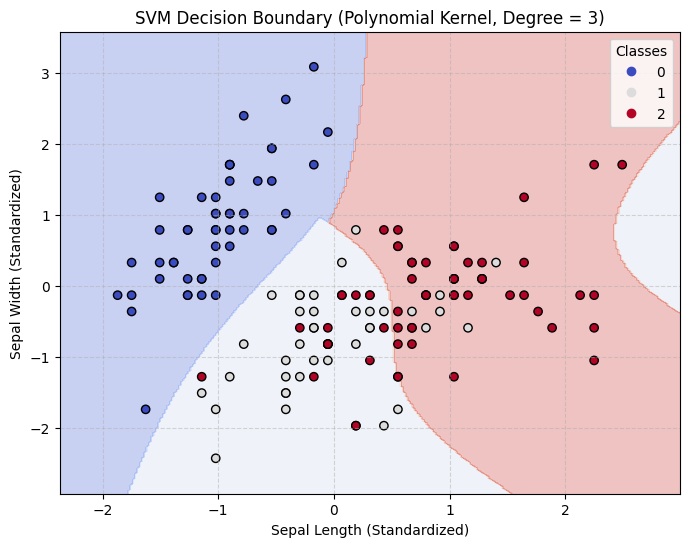

In [4]:
# 24. Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision
# boundary.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
iris = load_iris()
X = iris.data[:, :2]
y = iris.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
svm_poly = SVC(kernel='poly', degree=3, C=1.0, coef0=1.0, random_state=42)
svm_poly.fit(X_scaled, y)
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)
Z = svm_poly.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k'
)
plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Sepal Width (Standardized)")
plt.title("SVM Decision Boundary (Polynomial Kernel, Degree = 3)")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [5]:
# 25. Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and
# evaluate accuracy:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train)
y_pred = gnb_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Gaussian Naïve Bayes Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Gaussian Naïve Bayes Accuracy: 92.98%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

Confusion Matrix:
[[38  4]
 [ 4 68]]


In [6]:
# 26. Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20
# Newsgroups dataset.
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import make_pipeline
categories = [
    'alt.atheism',
    'soc.religion.christian',
    'comp.graphics',
    'sci.med'
]
train_data = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
test_data = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)
model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB(alpha=1.0)
)
model.fit(train_data.data, train_data.target)
y_pred = model.predict(test_data.data)
accuracy = accuracy_score(test_data.target, y_pred)
print(f"Multinomial Naïve Bayes Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(test_data.target, y_pred, target_names=train_data.target_names))

Multinomial Naïve Bayes Accuracy: 88.95%

Classification Report:
                        precision    recall  f1-score   support

           alt.atheism       0.97      0.72      0.83       319
         comp.graphics       0.95      0.95      0.95       389
               sci.med       0.95      0.88      0.92       396
soc.religion.christian       0.76      0.97      0.85       398

              accuracy                           0.89      1502
             macro avg       0.91      0.88      0.89      1502
          weighted avg       0.90      0.89      0.89      1502



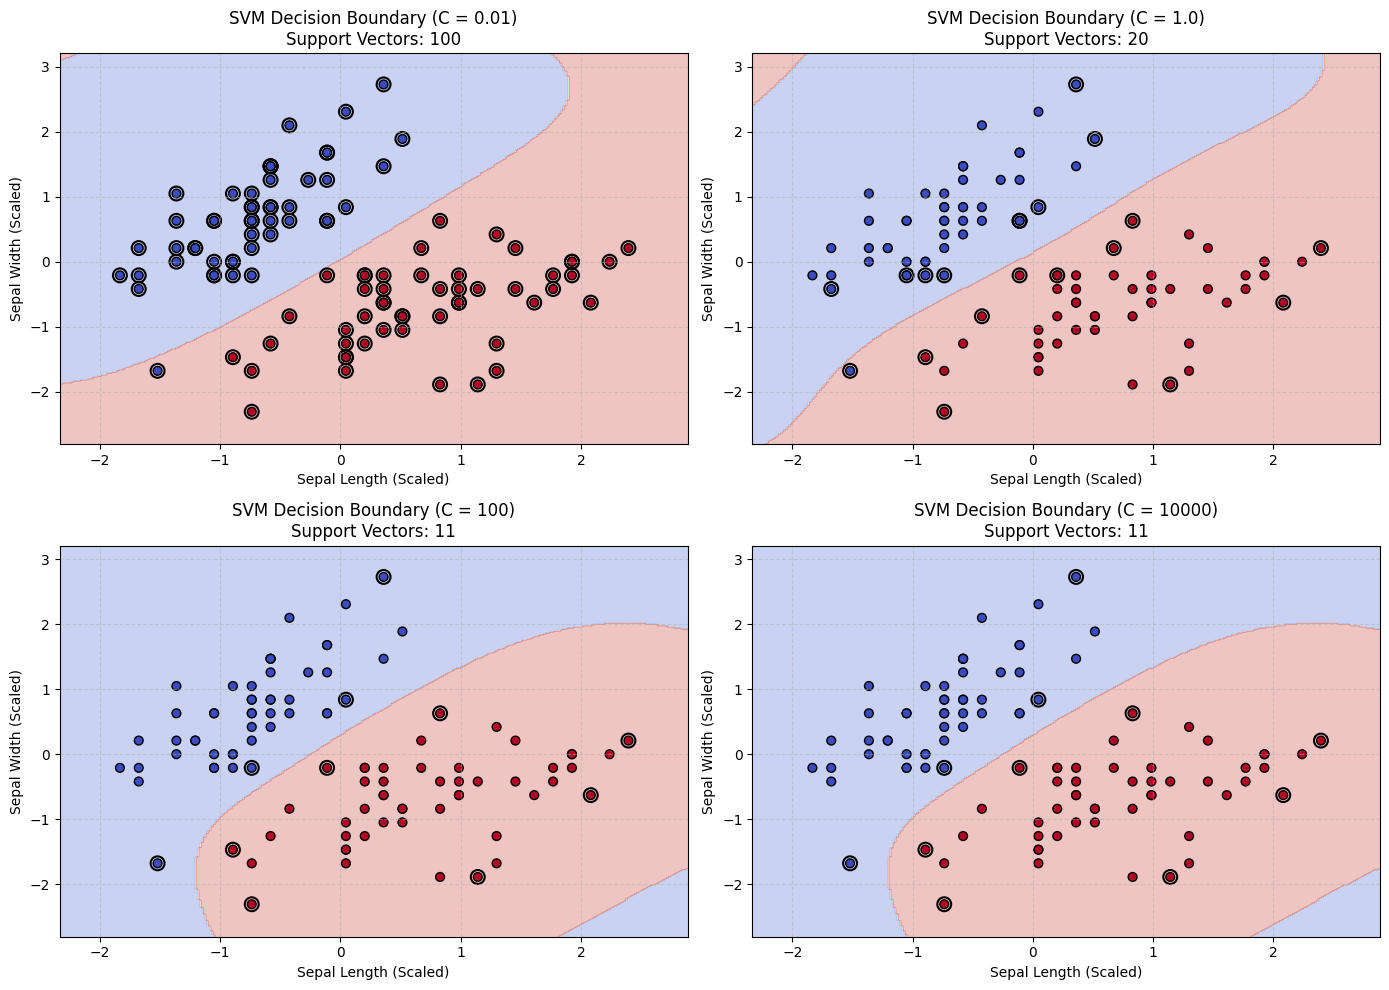

In [7]:
# 27. Write a Python program to train an SVM Classifier with different C values and compare the decision
# boundaries visually.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
iris = load_iris()
X = iris.data[:, :2]
y = iris.target

X = X[y != 2]
y = y[y != 2]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
c_values = [0.01, 1.0, 100, 10000]
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
plt.figure(figsize=(14, 10))

for idx, C in enumerate(c_values, 1):
    svm = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    svm.fit(X_scaled, y)
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.subplot(2, 2, idx)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,
                          cmap=plt.cm.coolwarm, edgecolors='k', s=40)
    plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
                s=100, facecolors='none', edgecolors='k', linewidths=1.5,
                label='Support Vectors')

    plt.title(f"SVM Decision Boundary (C = {C})\nSupport Vectors: {len(svm.support_vectors_)}")
    plt.xlabel("Sepal Length (Scaled)")
    plt.ylabel("Sepal Width (Scaled)")
    plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [8]:
# 28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with
# binary features.
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
np.random.seed(42)
X = np.random.randint(0, 2, size=(200, 10))
y = np.random.randint(0, 2, size=(200,))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
bernoulli_nb = BernoulliNB(alpha=1.0, binarize=None)
bernoulli_nb.fit(X_train, y_train)
y_pred = bernoulli_nb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Bernoulli Naïve Bayes Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Bernoulli Naïve Bayes Accuracy: 77.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79        21
           1       0.78      0.74      0.76        19

    accuracy                           0.78        40
   macro avg       0.78      0.77      0.77        40
weighted avg       0.78      0.78      0.77        40

Confusion Matrix:
[[17  4]
 [ 5 14]]


In [9]:
# 29. Write a Python program to apply feature scaling before training an SVM model and compare results with
# unscaled data.
import time
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
unscaled_svm = SVC(kernel='rbf', C=1.0, random_state=42)
start_time = time.time()
unscaled_svm.fit(X_train, y_test if False else y_train)
unscaled_train_time = time.time() - start_time
y_pred_unscaled = unscaled_svm.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaled_svm = SVC(kernel='rbf', C=1.0, random_state=42)
start_time = time.time()
scaled_svm.fit(X_train_scaled, y_train)
scaled_train_time = time.time() - start_time
y_pred_scaled = scaled_svm.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)
print("=" * 60)
print("             SVM FEATURE SCALING COMPARISON RESULTS         ")
print("=" * 60)
print(f"Unscaled Data Accuracy: {acc_unscaled * 100:.2f}% | Training Time: {unscaled_train_time:.5f}s")
print(f"Scaled Data Accuracy:   {acc_scaled * 100:.2f}% | Training Time: {scaled_train_time:.5f}s")
print("=" * 60)
print("\nClassification Report (Unscaled Data):")
print(classification_report(y_test, y_pred_unscaled, target_names=wine.target_names, zero_division=0))
print("Classification Report (Scaled Data):")
print(classification_report(y_test, y_pred_scaled, target_names=wine.target_names))

             SVM FEATURE SCALING COMPARISON RESULTS         
Unscaled Data Accuracy: 69.44% | Training Time: 0.00247s
Scaled Data Accuracy:   97.22% | Training Time: 0.00194s

Classification Report (Unscaled Data):
              precision    recall  f1-score   support

     class_0       0.92      0.92      0.92        12
     class_1       0.61      1.00      0.76        14
     class_2       0.00      0.00      0.00        10

    accuracy                           0.69        36
   macro avg       0.51      0.64      0.56        36
weighted avg       0.54      0.69      0.60        36

Classification Report (Scaled Data):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.

In [10]:
# 30. Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and
# after Laplace Smoothing.
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
train_docs = [
    "free loan money offer",
    "call now money",
    "meeting schedule project report",
    "project deadline report"
]
y_train = np.array(["spam", "spam", "ham", "ham"])
test_docs = ["urgent money offer"]

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_docs)
X_test = vectorizer.transform(test_docs)
nb_no_smoothing = MultinomialNB(alpha=1e-10)
nb_no_smoothing.fit(X_train, y_train)

pred_no_smooth = nb_no_smoothing.predict(X_test)[0]
proba_no_smooth = nb_no_smoothing.predict_proba(X_test)[0]
nb_with_smoothing = MultinomialNB(alpha=1.0)
nb_with_smoothing.fit(X_train, y_train)
pred_smooth = nb_with_smoothing.predict(X_test)[0]
proba_smooth = nb_with_smoothing.predict_proba(X_test)[0]
classes = nb_with_smoothing.classes_
print("=" * 65)
print(f"Test Document: '{test_docs[0]}'")
print("=" * 65)
print("\n[1] WITHOUT LAPLACE SMOOTHING (alpha ≈ 0):")
print(f"    Predicted Class: {pred_no_smooth}")
print(f"    Probabilities:   {dict(zip(classes, np.round(proba_no_smooth, 4)))}")
print("\n[2] WITH LAPLACE SMOOTHING (alpha = 1.0):")
print(f"    Predicted Class: {pred_smooth}")
print(f"    Probabilities:   {dict(zip(classes, np.round(proba_smooth, 4)))}")
print("=" * 65)

Test Document: 'urgent money offer'

[1] WITHOUT LAPLACE SMOOTHING (alpha ≈ 0):
    Predicted Class: spam
    Probabilities:   {np.str_('ham'): np.float64(0.0), np.str_('spam'): np.float64(1.0)}

[2] WITH LAPLACE SMOOTHING (alpha = 1.0):
    Predicted Class: spam
    Probabilities:   {np.str_('ham'): np.float64(0.1429), np.str_('spam'): np.float64(0.8571)}


In [11]:
# 31. Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C,
# gamma, kernel).

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'degree': [2, 3],
        'gamma': ['scale', 'auto']
    }
]
base_svm = SVC(random_state=42)
grid_search = GridSearchCV(
    estimator=base_svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print("=" * 60)
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best 5-Fold CV Accuracy: {grid_search.best_score_ * 100:.2f}%")
print("=" * 60)

best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Set Accuracy (Best Model): {test_accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Hyperparameters: {'C': 0.1, 'kernel': 'linear'}
Best 5-Fold CV Accuracy: 98.62%

Test Set Accuracy (Best Model): 97.22%

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


In [12]:
# 32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and
# check it improve accuracy.
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    weights=[0.90, 0.10],
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
standard_svm = SVC(kernel='rbf', C=1.0, random_state=42)
standard_svm.fit(X_train_scaled, y_train)
y_pred_std = standard_svm.predict(X_test_scaled)
balanced_svm = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
balanced_svm.fit(X_train_scaled, y_train)
y_pred_bal = balanced_svm.predict(X_test_scaled)
print("=" * 65)
print("             SVM IMBALANCED DATASET EVALUATION               ")
print("=" * 65)
print(f"Standard SVM Accuracy: {accuracy_score(y_test, y_pred_std) * 100:.2f}%")
print(f"Balanced SVM Accuracy: {accuracy_score(y_test, y_pred_bal) * 100:.2f}%")
print("=" * 65)

print("\n--- Model 1: Standard SVM Classification Report ---")
print(classification_report(y_test, y_pred_std, target_names=['Majority (0)', 'Minority (1)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_std))

print("\n--- Model 2: Class-Weighted SVM Classification Report ---")
print(classification_report(y_test, y_pred_bal, target_names=['Majority (0)', 'Minority (1)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bal))

             SVM IMBALANCED DATASET EVALUATION               
Standard SVM Accuracy: 92.50%
Balanced SVM Accuracy: 90.50%

--- Model 1: Standard SVM Classification Report ---
              precision    recall  f1-score   support

Majority (0)       0.92      1.00      0.96       179
Minority (1)       1.00      0.29      0.44        21

    accuracy                           0.93       200
   macro avg       0.96      0.64      0.70       200
weighted avg       0.93      0.93      0.91       200

Confusion Matrix:
[[179   0]
 [ 15   6]]

--- Model 2: Class-Weighted SVM Classification Report ---
              precision    recall  f1-score   support

Majority (0)       0.95      0.94      0.95       179
Minority (1)       0.54      0.62      0.58        21

    accuracy                           0.91       200
   macro avg       0.75      0.78      0.76       200
weighted avg       0.91      0.91      0.91       200

Confusion Matrix:
[[168  11]
 [  8  13]]


In [13]:
# 33.  Write a Python program to implement a Naïve Bayes classifier for spam detection using email data.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
data = {
    'text': [
        "Win a $1000 Walmart gift card now! Click here to claim.",
        "Hey, are we still meeting for lunch today at 12?",
        "URGENT: Your account has been compromised. Verify password now.",
        "Please find attached the project status report for Q3.",
        "Congratulations! You have been selected for a free vacation.",
        "Can you send over the updated slides for tomorrow's presentation?",
        "Earn $5000 a week working from home! No experience required.",
        "Don't forget to buy milk and eggs on your way home."
    ],
    'label': ['spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham']
}

df = pd.DataFrame(data)
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.25,
    random_state=42,
    stratify=df['label']
)
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
spam_detector = MultinomialNB(alpha=1.0)
spam_detector.fit(X_train_tfidf, y_train)
y_pred = spam_detector.predict(X_test_tfidf)
print("=" * 55)
print("             SPAM DETECTION EVALUATION RESULTS           ")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='spam') * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred, pos_label='spam') * 100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred, pos_label='spam') * 100:.2f}%")
print("=" * 55)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
new_emails = [
    "Exclusive deal! Click here to get free cash now!",
    "Hi, let me know when you are free to review the document."
]

new_emails_tfidf = vectorizer.transform(new_emails)
predictions = spam_detector.predict(new_emails_tfidf)
probabilities = spam_detector.predict_proba(new_emails_tfidf)

print("\n--- Live Custom Email Predictions ---")
for email, pred, prob in zip(new_emails, predictions, probabilities):
    spam_prob = prob[list(spam_detector.classes_).index('spam')]
    print(f"\nEmail: '{email}'")
    print(f"Prediction: {pred.upper()} (Spam Probability: {spam_prob * 100:.2f}%)")

             SPAM DETECTION EVALUATION RESULTS           
Accuracy:  50.00%
Precision: 0.00%
Recall:    0.00%
F1-Score:  0.00%

Classification Report:
              precision    recall  f1-score   support

         ham       0.50      1.00      0.67         1
        spam       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


--- Live Custom Email Predictions ---

Email: 'Exclusive deal! Click here to get free cash now!'
Prediction: SPAM (Spam Probability: 57.71%)

Email: 'Hi, let me know when you are free to review the document.'
Prediction: HAM (Spam Probability: 50.00%)


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

In [14]:
# 34. Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and
# compare their accuracy.
import time
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
dataset = load_breast_cancer()
X, y = dataset.data, dataset.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

start_svm = time.time()
svm_model.fit(X_train_scaled, y_train)
svm_time = time.time() - start_svm

y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
nb_model = GaussianNB()

start_nb = time.time()
nb_model.fit(X_train_scaled, y_train)
nb_time = time.time() - start_nb

y_pred_nb = nb_model.predict(X_test_scaled)
acc_nb = accuracy_score(y_test, y_pred_nb)
print("=" * 60)
print("             SVM vs. NAÏVE BAYES COMPARISON                  ")
print("=" * 60)
print(f"SVM (RBF Kernel) Accuracy: {acc_svm * 100:.2f}% | Training Time: {svm_time:.6f}s")
print(f"Gaussian Naïve Bayes Acc:  {acc_nb * 100:.2f}% | Training Time: {nb_time:.6f}s")
print("=" * 60)

print("\n--- Support Vector Machine Classification Report ---")
print(classification_report(y_test, y_pred_svm, target_names=dataset.target_names))

print("--- Gaussian Naïve Bayes Classification Report ---")
print(classification_report(y_test, y_pred_nb, target_names=dataset.target_names))

             SVM vs. NAÏVE BAYES COMPARISON                  
SVM (RBF Kernel) Accuracy: 98.25% | Training Time: 0.007607s
Gaussian Naïve Bayes Acc:  92.98% | Training Time: 0.002469s

--- Support Vector Machine Classification Report ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- Gaussian Naïve Bayes Classification Report ---
              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [15]:
# 35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare
# results.
import time
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'talk.religion.misc']

train_data = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
test_data = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
X_train = vectorizer.fit_transform(train_data.data)
X_test = vectorizer.transform(test_data.data)
y_train, y_test = train_data.target, test_data.target
nb_full = MultinomialNB(alpha=1.0)

start_full = time.time()
nb_full.fit(X_train, y_train)
fit_time_full = time.time() - start_full

y_pred_full = nb_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)
selector = SelectKBest(score_func=chi2, k=2000)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

nb_selected = MultinomialNB(alpha=1.0)

start_sel = time.time()
nb_selected.fit(X_train_selected, y_train)
fit_time_sel = time.time() - start_sel

y_pred_sel = nb_selected.predict(X_test_selected)
acc_sel = accuracy_score(y_test, y_pred_sel)
print("=" * 65)
print("     NAÏVE BAYES FEATURE SELECTION COMPARISON (CHI-SQUARED)     ")
print("=" * 65)
print(f"Original Feature Space Size:  {X_train.shape[1]} features")
print(f"Selected Feature Space Size:  {X_train_selected.shape[1]} features")
print("-" * 65)
print(f"Accuracy (All Features):      {acc_full * 100:.2f}% | Fit Time: {fit_time_full:.6f}s")
print(f"Accuracy (Top 2000 Features): {acc_sel * 100:.2f}% | Fit Time: {fit_time_sel:.6f}s")
print("=" * 65)
print("\n--- Classification Report (Selected Features) ---")
print(classification_report(y_test, y_pred_sel, target_names=train_data.target_names))

     NAÏVE BAYES FEATURE SELECTION COMPARISON (CHI-SQUARED)     
Original Feature Space Size:  10000 features
Selected Feature Space Size:  2000 features
-----------------------------------------------------------------
Accuracy (All Features):      87.45% | Fit Time: 0.007407s
Accuracy (Top 2000 Features): 86.72% | Fit Time: 0.003755s

--- Classification Report (Selected Features) ---
                    precision    recall  f1-score   support

       alt.atheism       0.77      0.86      0.81       319
     comp.graphics       0.91      0.97      0.94       389
           sci.med       0.91      0.91      0.91       396
talk.religion.misc       0.87      0.64      0.74       251

          accuracy                           0.87      1355
         macro avg       0.86      0.85      0.85      1355
      weighted avg       0.87      0.87      0.86      1355



In [16]:
# 36. Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO)
# strategies on the Wine dataset and compare their accuracy.
import time
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
base_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
ovr_model = OneVsRestClassifier(base_svm)

start_ovr = time.time()
ovr_model.fit(X_train_scaled, y_train)
time_ovr = time.time() - start_ovr

y_pred_ovr = ovr_model.predict(X_test_scaled)
acc_ovr = accuracy_score(y_test, y_pred_ovr)
ovo_model = OneVsOneClassifier(base_svm)

start_ovo = time.time()
ovo_model.fit(X_train_scaled, y_train)
time_ovo = time.time() - start_ovo

y_pred_ovo = ovo_model.predict(X_test_scaled)
acc_ovo = accuracy_score(y_test, y_pred_ovo)
print("=" * 65)
print("          MULTICLASS STRATEGY COMPARISON: OvR vs OvO          ")
print("=" * 65)
print(f"One-vs-Rest (OvR) Accuracy: {acc_ovr * 100:.2f}% | Training Time: {time_ovr:.6f}s")
print(f"One-vs-One  (OvO) Accuracy: {acc_ovo * 100:.2f}% | Training Time: {time_ovo:.6f}s")
print("=" * 65)
print("\n--- One-vs-Rest (OvR) Classification Report ---")
print(classification_report(y_test, y_pred_ovr, target_names=wine.target_names))
print("--- One-vs-One (OvO) Classification Report ---")
print(classification_report(y_test, y_pred_ovo, target_names=wine.target_names))

          MULTICLASS STRATEGY COMPARISON: OvR vs OvO          
One-vs-Rest (OvR) Accuracy: 97.22% | Training Time: 0.012011s
One-vs-One  (OvO) Accuracy: 97.22% | Training Time: 0.009420s

--- One-vs-Rest (OvR) Classification Report ---
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

--- One-vs-One (OvO) Classification Report ---
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted a

In [17]:
# 37.  Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast
# Cancer dataset and compare their accuracy.
import time
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
kernels = {
    'Linear Kernel': SVC(kernel='linear', C=1.0, random_state=42),
    'Polynomial Kernel (d=3)': SVC(kernel='poly', degree=3, C=1.0, coef0=1.0, random_state=42),
    'RBF Kernel': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
}

results = {}
for name, model in kernels.items():
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    results[name] = {
        'accuracy': acc,
        'train_time': train_time,
        'y_pred': y_pred
    }
print("=" * 65)
print("       SVM KERNEL COMPARISON ON BREAST CANCER DATASET         ")
print("=" * 65)
for name, res in results.items():
    print(f"{name:<25} | Accuracy: {res['accuracy'] * 100:.2f}% | Time: {res['train_time']:.5f}s")
print("=" * 65)
for name, res in results.items():
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, res['y_pred'], target_names=cancer.target_names))

       SVM KERNEL COMPARISON ON BREAST CANCER DATASET         
Linear Kernel             | Accuracy: 97.37% | Time: 0.00645s
Polynomial Kernel (d=3)   | Accuracy: 97.37% | Time: 0.00523s
RBF Kernel                | Accuracy: 98.25% | Time: 0.00691s

--- Linear Kernel Classification Report ---
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


--- Polynomial Kernel (d=3) Classification Report ---
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       11

In [18]:
# 38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy.
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
wine = load_wine()
X, y = wine.data, wine.target
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

print("=" * 60)
print("     STRATIFIED K-FOLD CROSS-VALIDATION FOR SVM (K=5)      ")
print("=" * 60)
for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled = scaler.transform(X_test_fold)
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    svm.fit(X_train_scaled, y_train_fold)
    y_pred = svm.predict(X_test_scaled)
    acc = accuracy_score(y_test_fold, y_pred)
    fold_accuracies.append(acc)

    print(f"Fold {fold}: Accuracy = {acc * 100:.2f}%")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print("=" * 60)
print(f"Mean Accuracy:               {mean_accuracy * 100:.2f}%")
print(f"Standard Deviation (±):     {std_accuracy * 100:.2f}%")
print("=" * 60)

     STRATIFIED K-FOLD CROSS-VALIDATION FOR SVM (K=5)      
Fold 1: Accuracy = 94.44%
Fold 2: Accuracy = 100.00%
Fold 3: Accuracy = 97.22%
Fold 4: Accuracy = 100.00%
Fold 5: Accuracy = 100.00%
Mean Accuracy:               98.33%
Standard Deviation (±):     2.22%


In [19]:
# 39. Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance.
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    weights=[0.80, 0.20],
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
prior_configs = {
    "Empirical (Default)": None,
    "Uniform Priors": [0.50, 0.50],
    "Minority Boosted": [0.30, 0.70],
    "Majority Biased": [0.90, 0.10]
}

results = []
for config_name, priors in prior_configs.items():
    gnb = GaussianNB(priors=priors)
    gnb.fit(X_train_scaled, y_train)

    y_pred = gnb.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "Prior Configuration": config_name,
        "Priors Used": str(priors) if priors else "Empirical Data",
        "Accuracy": f"{acc * 100:.2f}%",
        "Precision (C1)": f"{prec * 100:.2f}%",
        "Recall (C1)": f"{rec * 100:.2f}%",
        "F1-Score (C1)": f"{f1 * 100:.2f}%",
        "Confusion Matrix [TN, FP / FN, TP]": f"[{cm[0,0]}, {cm[0,1]} / {cm[1,0]}, {cm[1,1]}]"
    })
results_df = pd.DataFrame(results)
print("=" * 110)
print("                    GAUSSIAN NAÏVE BAYES: PRIOR PROBABILITY COMPARISON                    ")
print("=" * 110)
print(results_df.to_string(index=False))
print("=" * 110)

                    GAUSSIAN NAÏVE BAYES: PRIOR PROBABILITY COMPARISON                    
Prior Configuration    Priors Used Accuracy Precision (C1) Recall (C1) F1-Score (C1) Confusion Matrix [TN, FP / FN, TP]
Empirical (Default) Empirical Data   83.00%         62.96%      41.46%        50.00%                 [149, 10 / 24, 17]
     Uniform Priors     [0.5, 0.5]   70.00%         38.55%      78.05%        51.61%                  [108, 51 / 9, 32]
   Minority Boosted     [0.3, 0.7]   62.00%         33.33%      85.37%        47.95%                   [89, 70 / 6, 35]
    Majority Biased     [0.9, 0.1]   81.50%         70.00%      17.07%        27.45%                   [156, 3 / 34, 7]


In [20]:
# 40. Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy.
import time
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm_full = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

start_full = time.time()
svm_full.fit(X_train_scaled, y_train)
time_full = time.time() - start_full

y_pred_full = svm_full.predict(X_test_scaled)
acc_full = accuracy_score(y_test, y_pred_full)
estimator = SVC(kernel='linear', C=1.0, random_state=42)
rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

svm_rfe = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

start_rfe = time.time()
svm_rfe.fit(X_train_rfe, y_train)
time_rfe = time.time() - start_rfe

y_pred_rfe = svm_rfe.predict(X_test_rfe)
acc_rfe = accuracy_score(y_test, y_pred_rfe)

print("=" * 65)
print("       SVM RECURSIVE FEATURE ELIMINATION (RFE) COMPARISON       ")
print("=" * 65)
print(f"Full Feature Space:     {X_train.shape[1]} Features")
print(f"RFE Selected Space:     {X_train_rfe.shape[1]} Features")
print("-" * 65)
print(f"Accuracy (All Features): {acc_full * 100:.2f}% | Fit Time: {time_full:.5f}s")
print(f"Accuracy (RFE Top 10):   {acc_rfe * 100:.2f}% | Fit Time: {time_rfe:.5f}s")
print("=" * 65)
selected_features = cancer.feature_names[rfe.support_]
print("\nTop 10 Features Selected by RFE:")
for idx, feature_name in enumerate(selected_features, 1):
    print(f"  {idx}. {feature_name}")

print("\n--- Classification Report (RFE Top 10 Features) ---")
print(classification_report(y_test, y_pred_rfe, target_names=cancer.target_names))

       SVM RECURSIVE FEATURE ELIMINATION (RFE) COMPARISON       
Full Feature Space:     30 Features
RFE Selected Space:     10 Features
-----------------------------------------------------------------
Accuracy (All Features): 98.25% | Fit Time: 0.00761s
Accuracy (RFE Top 10):   95.61% | Fit Time: 0.00483s

Top 10 Features Selected by RFE:
  1. mean radius
  2. mean perimeter
  3. mean compactness
  4. radius error
  5. area error
  6. worst texture
  7. worst area
  8. worst smoothness
  9. worst concave points
  10. worst symmetry

--- Classification Report (RFE Top 10 Features) ---
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [21]:
# 41. Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy.
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)
y_probs = svm_model.predict_proba(X_test_scaled)[:, 1]
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
metrics_summary = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score', 'Macro F1', 'Weighted F1', 'ROC-AUC Score'],
    'Value': [f"{precision:.4f}", f"{recall:.4f}", f"{f1:.4f}", f"{macro_f1:.4f}", f"{weighted_f1:.4f}", f"{roc_auc:.4f}"]
})

print("=" * 60)
print("         SVM PERFORMANCE METRICS (EXCLUDING ACCURACY)       ")
print("=" * 60)
print(metrics_summary.to_string(index=False))
print("=" * 60)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

print("Confusion Matrix:")
print("  [TN  FP]")
print("  [FN  TP]")
print(confusion_matrix(y_test, y_pred))

         SVM PERFORMANCE METRICS (EXCLUDING ACCURACY)       
       Metric  Value
    Precision 0.9861
       Recall 0.9861
     F1-Score 0.9861
     Macro F1 0.9812
  Weighted F1 0.9825
ROC-AUC Score 0.9950

Detailed Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
  [TN  FP]
  [FN  TP]
[[41  1]
 [ 1 71]]


In [22]:
# 42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss(Cross-Entropy Loss).
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
gnb_uncalibrated = GaussianNB()
gnb_uncalibrated.fit(X_train_scaled, y_train)
probs_uncalibrated = gnb_uncalibrated.predict_proba(X_test_scaled)
preds_uncalibrated = gnb_uncalibrated.predict(X_test_scaled)

log_loss_uncalibrated = log_loss(y_test, probs_uncalibrated)
acc_uncalibrated = accuracy_score(y_test, preds_uncalibrated)
gnb_calibrated = CalibratedClassifierCV(estimator=GaussianNB(), method='sigmoid', cv=5)
gnb_calibrated.fit(X_train_scaled, y_train)

probs_calibrated = gnb_calibrated.predict_proba(X_test_scaled)
preds_calibrated = gnb_calibrated.predict(X_test_scaled)

log_loss_calibrated = log_loss(y_test, probs_calibrated)
acc_calibrated = accuracy_score(y_test, preds_calibrated)
summary_df = pd.DataFrame({
    'Model Configuration': ['Standard GaussianNB', 'Calibrated GaussianNB (Sigmoid)'],
    'Accuracy': [f"{acc_uncalibrated * 100:.2f}%", f"{acc_calibrated * 100:.2f}%"],
    'Log Loss (Lower is Better)': [f"{log_loss_uncalibrated:.5f}", f"{log_loss_calibrated:.5f}"],
    'Brier Score (Lower is Better)': [
        f"{brier_score_loss(y_test, probs_uncalibrated[:, 1]):.5f}",
        f"{brier_score_loss(y_test, probs_calibrated[:, 1]):.5f}"
    ]
})

print("=" * 75)
print("       NAÏVE BAYES LOG LOSS & PROBABILITY CALIBRATION EVALUATION       ")
print("=" * 75)
print(summary_df.to_string(index=False))
print("=" * 75)

       NAÏVE BAYES LOG LOSS & PROBABILITY CALIBRATION EVALUATION       
            Model Configuration Accuracy Log Loss (Lower is Better) Brier Score (Lower is Better)
            Standard GaussianNB   92.98%                    0.43696                       0.06019
Calibrated GaussianNB (Sigmoid)   92.98%                    0.22646                       0.05747


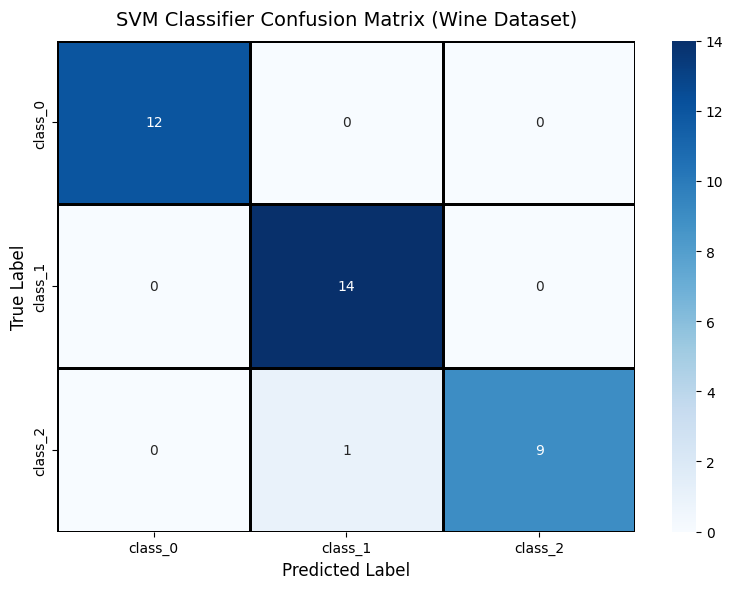

In [23]:
# 43. Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn.
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

wine = load_wine()
X, y = wine.data, wine.target
class_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    linewidths=1.0,
    linecolor='black'
)
plt.title('SVM Classifier Confusion Matrix (Wine Dataset)', fontsize=14, pad=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
# 44. Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE.
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
housing = fetch_california_housing()
X, y = housing.data[:2000], housing.target[:2000]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1, gamma='scale')
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
metrics_df = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R² Score'],
    'Value': [f"{mae:.4f}", f"{mse:.4f}", f"{rmse:.4f}", f"{r2:.4f}"]
})

print("=" * 60)
print("            SUPPORT VECTOR REGRESSOR (SVR) EVALUATION          ")
print("=" * 60)
print(metrics_df.to_string(index=False))
print("=" * 60)

            SUPPORT VECTOR REGRESSOR (SVR) EVALUATION          
                        Metric  Value
     Mean Absolute Error (MAE) 0.2580
      Mean Squared Error (MSE) 0.1547
Root Mean Squared Error (RMSE) 0.3933
                      R² Score 0.8306


       GAUSSIAN NAÏVE BAYES ROC-AUC EVALUATION        
Accuracy Score: 92.98%
ROC-AUC Score:  0.9868


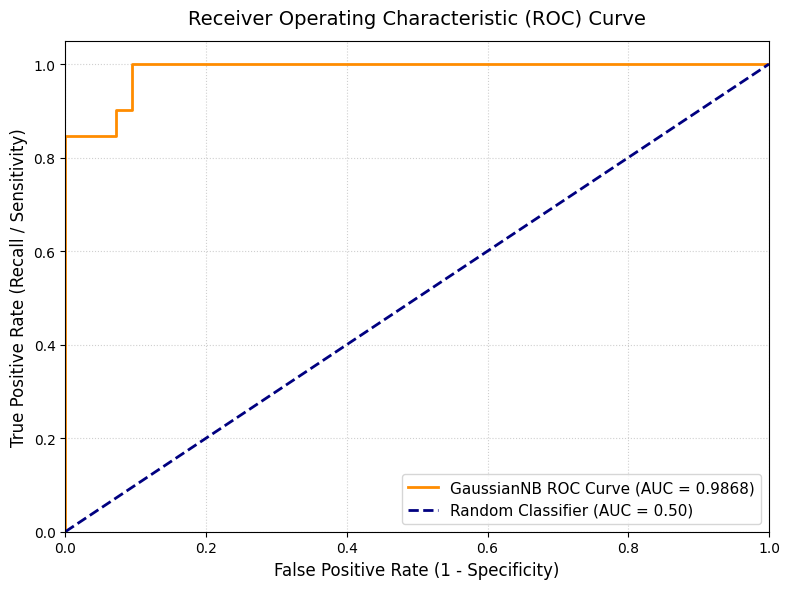

In [26]:
# 45. Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score.
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_probs = gnb.predict_proba(X_test_scaled)[:, 1]
y_pred = gnb.predict(X_test_scaled)
roc_auc = roc_auc_score(y_test, y_probs)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

print("=" * 55)
print("       GAUSSIAN NAÏVE BAYES ROC-AUC EVALUATION        ")
print("=" * 55)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC-AUC Score:  {roc_auc:.4f}")
print("=" * 55)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'GaussianNB ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

       SVM PRECISION-RECALL EVALUATION SUMMARY        
Average Precision (AP / PR-AUC): 0.9969


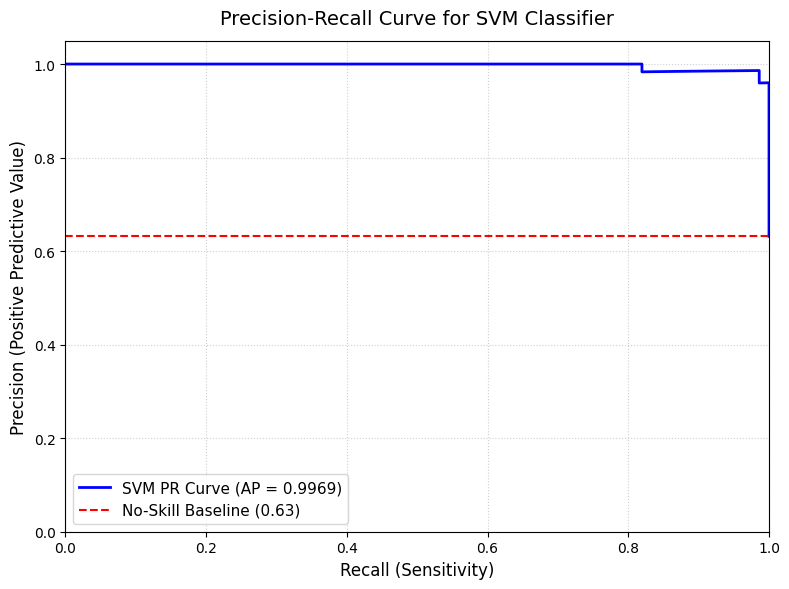

In [25]:
# 46. Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, average_precision_score

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_probs = svm.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

print("=" * 55)
print("       SVM PRECISION-RECALL EVALUATION SUMMARY        ")
print("=" * 55)
print(f"Average Precision (AP / PR-AUC): {ap_score:.4f}")
print("=" * 55)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'SVM PR Curve (AP = {ap_score:.4f})')

no_skill_baseline = sum(y_test) / len(y_test)
plt.plot([0, 1], [no_skill_baseline, no_skill_baseline], color='red', linestyle='--', label=f'No-Skill Baseline ({no_skill_baseline:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curve for SVM Classifier', fontsize=14, pad=12)
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()